<a href="https://colab.research.google.com/github/agcaubagit/Colab/blob/main/Generate_S1_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import shapely
import geemap
import folium
import pprint
import geopandas

print("Packages installed successfully!")

Packages installed successfully!


In [ ]:
# Google Earth Engine Authentication
import ee
ee.Authenticate()

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import ee
import time
import math
import json
import folium
import subprocess
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from numpy import sort
from pprint import pprint
from folium import plugins
from functools import reduce
from IPython.display import Image
from IPython.display import display
from shapely.geometry import Point

# Pandas modules to interact with spatial data
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame
from scipy.signal import argrelextrema
from shapely.geometry import Point,Polygon


import pprint
import geemap

# Configure the pretty printing output & initialize earthengine.
pp = pprint.PrettyPrinter(depth=4)
print("Success")

Success


In [ ]:
# Google Earth Engine Authentication
ee.Authenticate()

True

In [ ]:
# Google Earth Initialization
# Change 'ee-chriscandido93' to an existing cloud project
ee.Initialize(project='ee-agcauba')
# ee.Initialize(project='ee-leads')
print("Success")

Success


In [ ]:
def feature2ee(file):
    """
    Converts a shapefile or CSV file to an Earth Engine FeatureCollection.

    Parameters:
    file (str): Path to the input shapefile (.shp) or CSV file (.csv).

    Returns:
    ee.FeatureCollection: An Earth Engine FeatureCollection object.
    """
    try:
        # Check if the file is a shapefile
        if file.endswith('.shp'):
            # Ensure file path is correct and the file exists, handle potential errors
            try:
                gdf = gpd.read_file(file, encoding="utf-8")
            except FileNotFoundError:
                print(f"Error: File not found at {file}")
                return None
            except Exception as e:
                print(f"Error reading shapefile: {e}")
                return None

            # Print some info to check if the file was read correctly
            print(gdf.head())
            print(gdf.geom_type[0])
            g = [i for i in gdf.geometry]
            features = []

            # For Polygon or MultiPolygon geo data types
            if gdf.geom_type[0] in ['Polygon', 'MultiPolygon']:
                for i in range(len(g)):
                    geom = g[i]

                    if geom.geom_type == 'Polygon':  # Single polygon case
                        x, y = geom.exterior.coords.xy
                        cords = np.dstack((x, y)).tolist()
                        ee_geom = ee.Geometry.Polygon(cords)
                        properties = gdf.iloc[i].drop('geometry').to_dict()
                        feature = ee.Feature(ee_geom, properties)
                        features.append(feature)

                    elif geom.geom_type == 'MultiPolygon':  # MultiPolygon case
                        for poly in geom.geoms:  # Use .geoms to access each polygon in MultiPolygon
                            x, y = poly.exterior.coords.xy
                            cords = np.dstack((x, y)).tolist()
                            ee_geom = ee.Geometry.Polygon(cords)
                            properties = gdf.iloc[i].drop('geometry').to_dict()
                            feature = ee.Feature(ee_geom, properties)
                            features.append(feature)
                print("Polygon/MultiPolygon conversion done")

            # For LineString geo data type
            elif gdf.geom_type[0] == 'LineString':
                for i in range(len(g)):
                    x, y = g[i].coords.xy
                    cords = np.dstack((x, y)).tolist()
                    double_list = reduce(lambda x, y: x + y, cords)
                    geom = ee.Geometry.LineString(double_list)
                    properties = gdf.iloc[i].drop('geometry').to_dict()
                    feature = ee.Feature(geom, properties)
                    features.append(feature)
                print("LineString conversion done")

            # For Point geo data type
            elif gdf.geom_type[0] == 'Point':
                for i in range(len(g)):
                    x, y = g[i].coords.xy
                    cords = np.dstack((x, y)).tolist()
                    double_list = reduce(lambda x, y: x + y, cords)
                    single_list = reduce(lambda x, y: x + y, double_list)
                    geom = ee.Geometry.Point(single_list)
                    properties = gdf.iloc[i].drop('geometry').to_dict()
                    feature = ee.Feature(geom, properties)
                    features.append(feature)
                print("Point conversion done")

            if not features:
                print("No features were created from the shapefile.")
                return None
            ee_object = ee.FeatureCollection(features)
            return ee_object

        # Check if the file is a CSV file
        elif file.endswith('.csv'):
            try:
                df = pd.read_csv(file)
            except FileNotFoundError:
                print(f"Error: File not found at {file}")
                return None
            except Exception as e:
                print(f"Error reading CSV file: {e}")
                return None

            print(df.head(10))  # Debugging step to check CSV contents
            features = []
            for i in range(df.shape[0]):
                try:
                    x, y = df['x'][i], df['y'][i]
                    latlong = [x, y]
                    geom = ee.Geometry.Point(latlong)
                    properties = df.iloc[i].drop(['x', 'y']).to_dict()
                    feature = ee.Feature(geom, properties)
                    features.append(feature)
                except Exception as e:
                    print(f"Error processing CSV row {i}: {e}")
            print("CSV conversion done")

            if not features:
                print("No features were created from the CSV.")
                return None
            ee_object = ee.FeatureCollection(features)
            return ee_object

    except Exception as e:
        print(f"Error: {e}")
        print("Incorrect file format or an error occurred during conversion.")
        return None

print("success")

success


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
AOI = feature2ee("/content/drive/My Drive/Leads/Sample.shp")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
    gps_lat     gps_lon crop_growt    crop_est_m crop_est_d  \
0  8.943787  125.604693    Booting  Transplanted   6-Jan-24   
1  8.951421  125.400114   Seedling  Transplanted  27-Jan-24   
2  8.902675  125.409173   Seedling  Transplanted  31-Jan-24   
3  8.716265  125.598080   Seedling  Transplanted  18-Jan-24   
4  8.721942  125.606408  Tillering  Transplanted  11-Jan-24   

                    geometry  
0  POINT (125.60469 8.94379)  
1  POINT (125.40011 8.95142)  
2  POINT (125.40917 8.90268)  
3  POINT (125.59808 8.71627)  
4  POINT (125.60641 8.72194)  
Point
Point conversion done


In [ ]:
# Define the coordinates of the bottom-left and top-right corners of your area
bottom_left = [120.5, 15.25]  # Longitude, Latitude
top_right = [120.5 + 0.25, 15.25 + 0.25]  # Add 0.5 degrees to both coordinates
#AOI = ee.Geometry.Rectangle([bottom_left, top_right])
# Create an interactive map
map = geemap.Map()
map.centerObject(AOI, 10)  # Center the map on the area with a zoom level of 10
map.addLayer(AOI, {}, 'Butuan')

# Display the map
map

Map(center=[8.88183569110298, 125.58361450192724], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
# Convert Google Earth Engine Object to Pandas Dataframe
def ee_to_pandas(ee_object):
    """Converts an ee.FeatureCollection to pandas dataframe.

    Args:
        ee_object (ee.FeatureCollection): ee.FeatureCollection.

    Raises:
        TypeError: ee_object must be an ee.FeatureCollection

    Returns:
        pd.DataFrame: pandas DataFrame
    """
    import pandas as pd

    if not isinstance(ee_object, ee.FeatureCollection):
        raise TypeError("ee_object must be an ee.FeatureCollection")

    try:
        data = ee_object.map(lambda f: ee.Feature(None, f.toDictionary()))
        data = [x["properties"] for x in data.getInfo()["features"]]
        df = pd.DataFrame(data)
        return df
    except Exception as e:
        raise Exception(e)

print("success")

success


In [ ]:
polarization = 'VV'

In [ ]:
def smoothing(image):

  return image.focalMode(**{'radius':1, 'kernelType':'circle', 'units':'pixels', 'iterations':1})

In [ ]:
def mask_edge(image):
  edge = image.lt(-30.0)
  masked_image = image.mask().And(edge.Not())
  return image.updateMask(masked_image)

In [ ]:
def convert_toLinear(image):

  db = image.expression('pow(10, db / 10)', {
      'db': image.select([polarization])
      }
    ).rename([polarization])

  return image.addBands(db)

In [ ]:
def refined_lee_filter(image, polarization=polarization, kernel_size=1):
    """
    Apply a Refined Lee filter to an image and set a custom name based on acquisition date.

    Parameters:
    - image: ee.Image, the input image to be filtered.
    - polarization: str, the polarization type (default 'VH').
    - kernel_size: int, the size of the square kernel in pixels (default 2).

    Returns:
    - ee.Image, the filtered image with a custom name and key property.
    """
    # Calculate the mean and variance
    mean = image.reduceNeighborhood(
        reducer=ee.Reducer.mean(),
        kernel=ee.Kernel.square(kernel_size, 'pixels')
    )

    variance = image.reduceNeighborhood(
        reducer=ee.Reducer.variance(),
        kernel=ee.Kernel.square(kernel_size, 'pixels')
    )

    # Compute the square of the mean
    mean_square = mean.pow(2)

    # Compute the noise variance
    noise_variance = variance.subtract(mean_square)

    # Calculate the ratio of the variance to the sum of the variance and noise variance
    weight = variance.divide(variance.add(noise_variance))

    # Apply the weight to the image
    filtered_image = mean.add(weight.multiply(image.subtract(mean)))

    # Retrieve the date and format it to YYYY-MM-DD
    date_str = ee.Date(image.get("system:time_start")).format("YYYY-MM-DD")

    # Set the custom name in the required format
    custom_name = date_str.cat(f"_S1{polarization}")

    # Set the name property and a custom key
    return (
        filtered_image.rename([polarization])
        .set("name", custom_name)  # Set the custom name
        .set("key", custom_name)   # Set a custom key
        .copyProperties(image, ["system:time_start", "system:id"])  # Retain important properties
    )

In [ ]:
def refined_lee_filter(image, polarization=polarization, kernel_size=3):
    """
    Apply the Refined Lee filter to a Sentinel-1 image with a custom name based on acquisition date.

    Parameters:
    - image: ee.Image, the input image to be filtered.
    - polarization: str, the polarization type (default 'VH').
    - kernel_size: int, the size of the square kernel in pixels (default 3).

    Returns:
    - ee.Image, the filtered image with a custom name and key property.
    """
    # Convert image from dB to linear scale
    img_linear = ee.Image.constant(10).pow(image.divide(10))

    # Set up kernels for neighborhood mean and variance
    kernel = ee.Kernel.square(kernel_size, 'pixels', False)

    # Calculate local mean and variance
    mean = img_linear.reduceNeighborhood(ee.Reducer.mean(), kernel)
    variance = img_linear.reduceNeighborhood(ee.Reducer.variance(), kernel)

    # Calculate noise variance (estimated from local statistics)
    sample_stats = variance.divide(mean.pow(2))
    noise_variance = sample_stats.toArray().arraySort().arraySlice(0, 0, 5).arrayReduce(
        ee.Reducer.mean(), [0]
    )

    # Apply the refined Lee filter formula
    varX = variance.subtract(mean.pow(2).multiply(noise_variance)).divide(noise_variance.add(1.0))
    b = varX.divide(variance)
    filtered_image = mean.add(b.multiply(img_linear.subtract(mean)))

    # Convert back to dB scale
    filtered_image_db = filtered_image.log10().multiply(10)

    # Retrieve the date and format it to YYYY-MM-DD
    date_str = ee.Date(image.get("system:time_start")).format("YYYY-MM-DD")

    # Set the custom name in the required format
    custom_name = date_str.cat(f"_S1{polarization}")

    # Set the name property and a custom key
    return (
        filtered_image_db.rename([polarization])
        .set("name", custom_name)  # Set the custom name
        .set("key", custom_name)   # Set a custom key
        .copyProperties(image, ["system:time_start", "system:id"])  # Retain important properties
    )


In [ ]:
# Define your Area of Interest (AOI)
area = AOI  # Replace with your actual AOI

# Date range for the image collection
startDate = '2023-01-01'
endDate = '2024-12-31'

# Sentinel-1 Image Collection setup
polarization = 'VH'  # Change this to your desired polarization

collectionS1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
                .filter(ee.Filter.eq('instrumentMode', 'IW'))
                .filterDate(startDate, endDate)
                .filter(ee.Filter.listContains('transmitterReceiverPolarisation', polarization))
                .filterBounds(area)
                .map(mask_edge))

# Filter by descending orbit properties only
collectionS1_desc = collectionS1.filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))

# Select VH band and apply a refined Lee filter
collectionS1_desc_VH = collectionS1_desc.select(['VH']).map(refined_lee_filter)

# Function to sample images at weekly intervals
def sample_images_at_intervals(collection, start_date, end_date, interval_days):
    date_list = ee.List.sequence(ee.Date(start_date).millis(), ee.Date(end_date).millis(), interval_days * 24 * 60 * 60 * 1000)

    def filter_and_get_image(millis):
        filtered = collection.filterDate(ee.Date(millis), ee.Date(millis).advance(interval_days, 'day')).mosaic()
        renamed_image = filtered.rename(polarization)
        image_date = ee.Date(millis).format('YYYY-MM-dd')
        image_name = ee.String('S1_Mosaic_').cat(image_date)
        return renamed_image.set('system:time_start', millis, 'system:id', image_name)

    sampled_images = date_list.map(filter_and_get_image)
    return ee.ImageCollection.fromImages(sampled_images)

# Sample images at weekly intervals
weekly_images_desc_mosaicked = sample_images_at_intervals(collectionS1_desc_VH, startDate, endDate, 1)

# Sort the weekly mosaicked images by date
sorted_combined_images = weekly_images_desc_mosaicked.sort('system:time_start')

pp.pprint(sorted_combined_images.getInfo())

{'bands': [],
 'features': [{'bands': [],
               'id': 'S1_Mosaic_2023-01-01',
               'properties': {'system:index': '0',
                              'system:time_start': 1672531200000},
               'type': 'Image'},
              {'bands': [{...}],
               'id': 'S1_Mosaic_2023-01-02',
               'properties': {'system:index': '1',
                              'system:time_start': 1672617600000},
               'type': 'Image'},
              {'bands': [],
               'id': 'S1_Mosaic_2023-01-03',
               'properties': {'system:index': '2',
                              'system:time_start': 1672704000000},
               'type': 'Image'},
              {'bands': [],
               'id': 'S1_Mosaic_2023-01-04',
               'properties': {'system:index': '3',
                              'system:time_start': 1672790400000},
               'type': 'Image'},
              {'bands': [],
               'id': 'S1_Mosaic_2023-01-05',
            

In [ ]:
# Initialize an empty list to store feature statistics
all_stats = []

# Define your Area of Interest (AOI)
area = AOI  # Replace with your actual AOI

# Date range for the image collection
startDate = '2023-01-01'
endDate = '2024-12-31'

# Define field
field = 'crop_est_m'
lat = 'gps_lat'
lon = 'gps_lon'
field_02 = 'crop_growt'
field_03 = 'crop_est_d'

# Get the list of feature IDs dynamically from AOI
feature_ids = AOI.aggregate_array("system:index").getInfo()

# Define statistics columns
max_val = polarization + '_max'
med = polarization + '_median'
min_val = polarization + '_min'

# Loop through each plot ID and process
for plot_id in feature_ids:
    print(f"Processing plot {plot_id}")

    # Get geometry for the current plot
    geom = AOI.filter(ee.Filter.eq("system:index", plot_id)).geometry()
    crop_est_info = AOI.filter(ee.Filter.eq("system:index", plot_id)).first()

    # Extract crop information and validate
    crop_est = crop_est_info.get(field).getInfo() if crop_est_info else None
    if crop_est is None:
        print(f"Skipping plot {plot_id} due to missing crop_est.")
        continue

    gps_lat = crop_est_info.get(lat).getInfo() if crop_est_info else None
    gps_lon = crop_est_info.get(lon).getInfo() if crop_est_info else None
    crop_growth = crop_est_info.get(field_02).getInfo() if crop_est_info else None
    crop_est_d = crop_est_info.get(field_03).getInfo() if crop_est_info else None

    print(f"Crop estimate for plot {plot_id}: {crop_est}")
    print(f"GPS Lat for plot {plot_id}: {gps_lat}")
    print(f"GPS Lon for plot {plot_id}: {gps_lon}")
    print(f"Crop growth for plot {plot_id}: {crop_growth}")
    print(f"Crop establishment date for plot {plot_id}: {crop_est_d}")

    # Sentinel-1 Image Collection setup for the specific plot
    collectionS1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
                    .filter(ee.Filter.eq('instrumentMode', 'IW'))
                    .filterDate(startDate, endDate)
                    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', polarization))
                    .filterBounds(geom)
                    .map(mask_edge))

    # Filter by descending orbit properties only
    collectionS1_desc = collectionS1.filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))

    # Select VH band and apply a refined Lee filter
    collectionS1_desc_VH = collectionS1_desc.select([polarization]).map(refined_lee_filter)

    if collectionS1_desc_VH.size().getInfo() > 0:
        # Function to process each image and extract stats
        def process_image(image):
            # Get statistics for the image
            stats = image.reduceRegion(
                reducer=ee.Reducer.median()
                    .combine(reducer2=ee.Reducer.min(), sharedInputs=True)
                    .combine(reducer2=ee.Reducer.max(), sharedInputs=True),
                geometry=geom,
                scale=30,
                bestEffort=True
            )

            # Create a dictionary with the required information
            stats_dict = {
                'date': image.date().format('YYYY-MM-dd').getInfo(),
                'plot': plot_id,
                max_val: stats.get(max_val).getInfo() if stats.get(max_val) else None,
                med: stats.get(med).getInfo() if stats.get(med) else None,
                min_val: stats.get(min_val).getInfo() if stats.get(min_val) else None,
                field: crop_est,
                'gps_lat': gps_lat,
                'gps_lon': gps_lon,
                'crop_growt': crop_growth,
                'crop_est_d': crop_est_d
            }

            # Append to global stats
            all_stats.append(stats_dict)

        # Apply the function over the collection
        collectionS1_desc_VH.toList(collectionS1_desc_VH.size()).getInfo()

        images = collectionS1_desc_VH.toList(collectionS1_desc_VH.size()).getInfo()
        for img_info in images:
            process_image(ee.Image(img_info['id']))
    else:
        print(f"No images available for plot {plot_id}. Skipping.")

# Convert all collected statistics to a Pandas DataFrame
df = pd.DataFrame(all_stats)

Processing plot 0
Crop estimate for plot 0: Transplanted
GPS Lat for plot 0: 8.9437871
GPS Lon for plot 0: 125.6046929
Crop growth for plot 0: Booting
Crop establishment date for plot 0: 6-Jan-24
Processing plot 1
Crop estimate for plot 1: Transplanted
GPS Lat for plot 1: 8.9514212
GPS Lon for plot 1: 125.400114
Crop growth for plot 1: Seedling
Crop establishment date for plot 1: 27-Jan-24
Processing plot 2
Crop estimate for plot 2: Transplanted
GPS Lat for plot 2: 8.9026754
GPS Lon for plot 2: 125.4091726
Crop growth for plot 2: Seedling
Crop establishment date for plot 2: 31-Jan-24
Processing plot 3
Crop estimate for plot 3: Transplanted
GPS Lat for plot 3: 8.7162652
GPS Lon for plot 3: 125.59808
Crop growth for plot 3: Seedling
Crop establishment date for plot 3: 18-Jan-24
Processing plot 4
Crop estimate for plot 4: Transplanted
GPS Lat for plot 4: 8.7219424
GPS Lon for plot 4: 125.6064081
Crop growth for plot 4: Tillering
Crop establishment date for plot 4: 11-Jan-24
Processing plo

In [ ]:
df # Print Dataframe

,date,plot,VH_max,VH_median,VH_min,crop_est_m,gps_lat,gps_lon,crop_growt,crop_est_d
0,2023-01-02,0,-23.172420,-23.172420,-23.172420,Transplanted,8.943787,125.604693,Booting,6-Jan-24
1,2023-01-14,0,-21.986616,-21.986616,-21.986616,Transplanted,8.943787,125.604693,Booting,6-Jan-24
2,2023-01-26,0,-16.547872,-16.547872,-16.547872,Transplanted,8.943787,125.604693,Booting,6-Jan-24
3,2023-02-07,0,-19.860080,-19.860080,-19.860080,Transplanted,8.943787,125.604693,Booting,6-Jan-24
4,2023-02-19,0,-17.107549,-17.107549,-17.107549,Transplanted,8.943787,125.604693,Booting,6-Jan-24
...,...,...,...,...,...,...,...,...,...,...
605,2024-11-04,9,-12.057890,-12.057890,-12.057890,Direct-Seeded,8.691527,125.745095,Seedling,3-Jan-24
606,2024-11-16,9,-17.803437,-17.803437,-17.803437,Direct-Seeded,8.691527,125.745095,Seedling,3-Jan-24
607,2024-11-28,9,-12.318104,-12.318104,-12.318104,Direct-Seeded,8.691527,125.745095,Seedling,3-Jan-24
608,2024-12-10,9,-13.930947,-13.930947,-13.930947,Direct-Seeded,8.691527,125.745095,Seedling,3-Jan-24


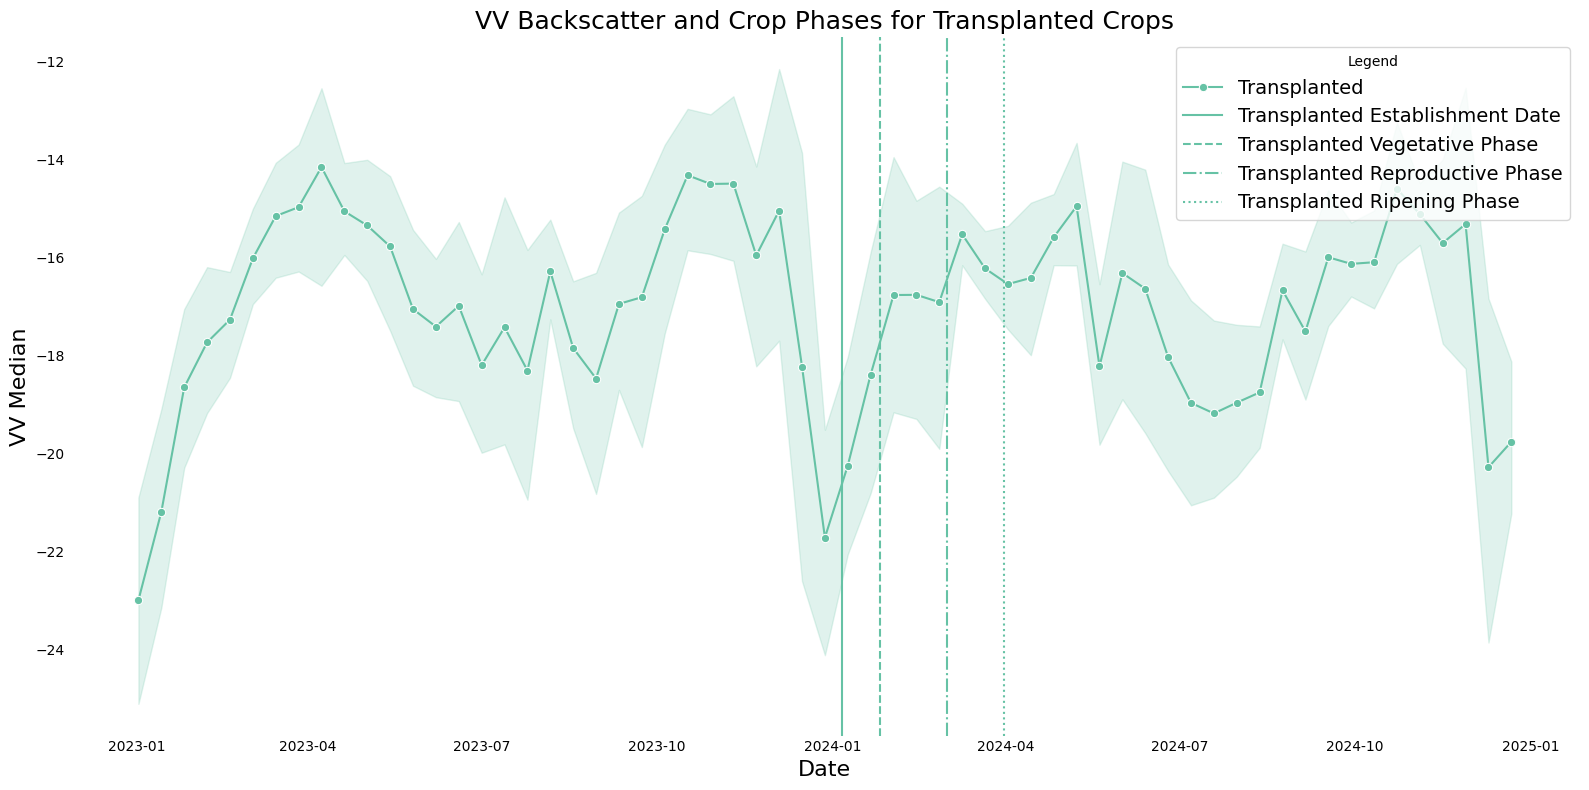

In [ ]:
# Convert date columns to datetime
df['date'] = pd.to_datetime(df['date'])
df['crop_est_d'] = pd.to_datetime(df['crop_est_d'])

# Define phase durations
VEGETATIVE_DAYS = 20
REPRODUCTIVE_DAYS = 35
RIPENING_DAYS = 30

# Define a color palette
palette = sns.color_palette('Set2', n_colors=1)  # Only one color since we show Transplanted
colors = {'Transplanted': palette[0]}

# Filter the dataframe for Transplanted only
df_transplanted = df[df['crop_est_m'] == 'Transplanted']

# Plot setup
plt.figure(figsize=(16, 8))  # Increased figure size for a larger plot

# Add the line plot for Transplanted VV backscatter
sns.lineplot(
    data=df_transplanted,
    x='date',
    y=med,
    hue='crop_est_m',
    marker='o',
    style='crop_est_m',
    palette=colors
)

# Add vertical lines for crop establishment and phases for Transplanted
for crop_type, group in df_transplanted.groupby('crop_est_m'):
    est_date = group['crop_est_d'].iloc[0]  # Use the first occurrence for the crop type

    # Calculate phase dates
    vegetative_date = est_date + pd.Timedelta(days=VEGETATIVE_DAYS)
    reproductive_date = vegetative_date + pd.Timedelta(days=REPRODUCTIVE_DAYS)
    ripening_date = reproductive_date + pd.Timedelta(days=RIPENING_DAYS)

    # Plot vertical lines for each phase
    plt.axvline(est_date, color=colors[crop_type], linestyle='-', label=f'{crop_type} Establishment Date')
    plt.axvline(vegetative_date, color=colors[crop_type], linestyle='--', label=f'{crop_type} Vegetative Phase')
    plt.axvline(reproductive_date, color=colors[crop_type], linestyle='-.', label=f'{crop_type} Reproductive Phase')
    plt.axvline(ripening_date, color=colors[crop_type], linestyle=':', label=f'{crop_type} Ripening Phase')

# Customize the plot
plt.title('VV Backscatter and Crop Phases for Transplanted Crops', fontsize=18)
plt.xlabel('Date', fontsize=16)
plt.ylabel('VV Median', fontsize=16)
plt.legend(title='Legend', fontsize=14, loc='upper right')

# Remove axis spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

# Remove grid lines and ticks extending from axis
plt.grid(False)  # Removes grid lines
plt.tick_params(axis='both', which='both', length=0)  # Removes tick marks

# Show the plot
plt.tight_layout()
plt.show()

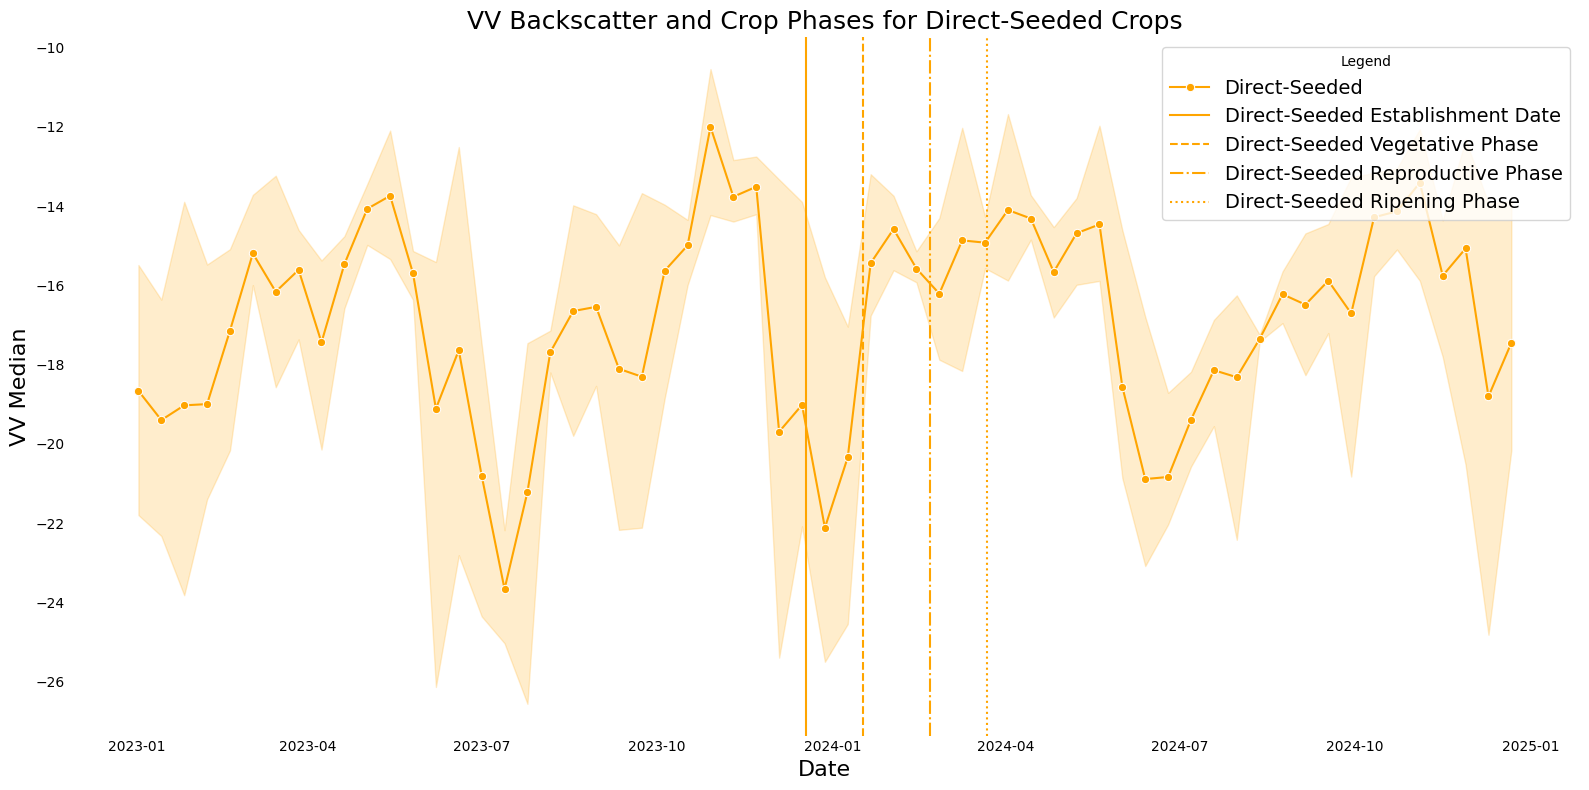

In [ ]:
# Convert date columns to datetime
df['date'] = pd.to_datetime(df['date'])
df['crop_est_d'] = pd.to_datetime(df['crop_est_d'])

# Define phase durations
VEGETATIVE_DAYS = 30
REPRODUCTIVE_DAYS = 35
RIPENING_DAYS = 30

# Set the color for Direct-Seeded crops to orange
colors = {'Direct-Seeded': 'orange'}

# Filter the dataframe for Direct-Seeded only
df_direct_seeded = df[df['crop_est_m'] == 'Direct-Seeded']

# Plot setup
plt.figure(figsize=(16, 8))  # Increased figure size for a larger plot

# Add the line plot for Direct-Seeded VH backscatter
sns.lineplot(
    data=df_direct_seeded,
    x='date',
    y=med,
    hue='crop_est_m',
    marker='o',
    style='crop_est_m',
    palette=colors
)

# Add vertical lines for crop establishment and phases for Direct-Seeded
for crop_type, group in df_direct_seeded.groupby('crop_est_m'):
    est_date = group['crop_est_d'].iloc[0]  # Use the first occurrence for the crop type

    # Calculate phase dates
    vegetative_date = est_date + pd.Timedelta(days=VEGETATIVE_DAYS)
    reproductive_date = vegetative_date + pd.Timedelta(days=REPRODUCTIVE_DAYS)
    ripening_date = reproductive_date + pd.Timedelta(days=RIPENING_DAYS)

    # Plot vertical lines for each phase
    plt.axvline(est_date, color=colors[crop_type], linestyle='-', label=f'{crop_type} Establishment Date')
    plt.axvline(vegetative_date, color=colors[crop_type], linestyle='--', label=f'{crop_type} Vegetative Phase')
    plt.axvline(reproductive_date, color=colors[crop_type], linestyle='-.', label=f'{crop_type} Reproductive Phase')
    plt.axvline(ripening_date, color=colors[crop_type], linestyle=':', label=f'{crop_type} Ripening Phase')

# Customize the plot
plt.title('VV Backscatter and Crop Phases for Direct-Seeded Crops', fontsize=18)
plt.xlabel('Date', fontsize=16)
plt.ylabel('VV Median', fontsize=16)
plt.legend(title='Legend', fontsize=14, loc='upper right')

# Remove axis spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

# Remove grid lines and ticks extending from axis
plt.grid(False)  # Removes grid lines
plt.tick_params(axis='both', which='both', length=0)  # Removes tick marks

# Show the plot
plt.tight_layout()
plt.show()

frac: 0.1, MSE: 10.1172
frac: 0.2, MSE: 10.3537
frac: 0.3, MSE: 10.4904
frac: 0.4, MSE: 10.5759
frac: 0.5, MSE: 10.5841
frac: 0.6, MSE: 10.6081
frac: 0.7, MSE: 10.6334
frac: 0.8, MSE: 10.6528
frac: 0.9, MSE: 10.6569
Best frac: 0.1, Best MSE: 10.1172


TypeError: functools.partial(<class 'matplotlib.lines.Line2D'>, xdata=[], ydata=[]) got multiple values for keyword argument 'label'

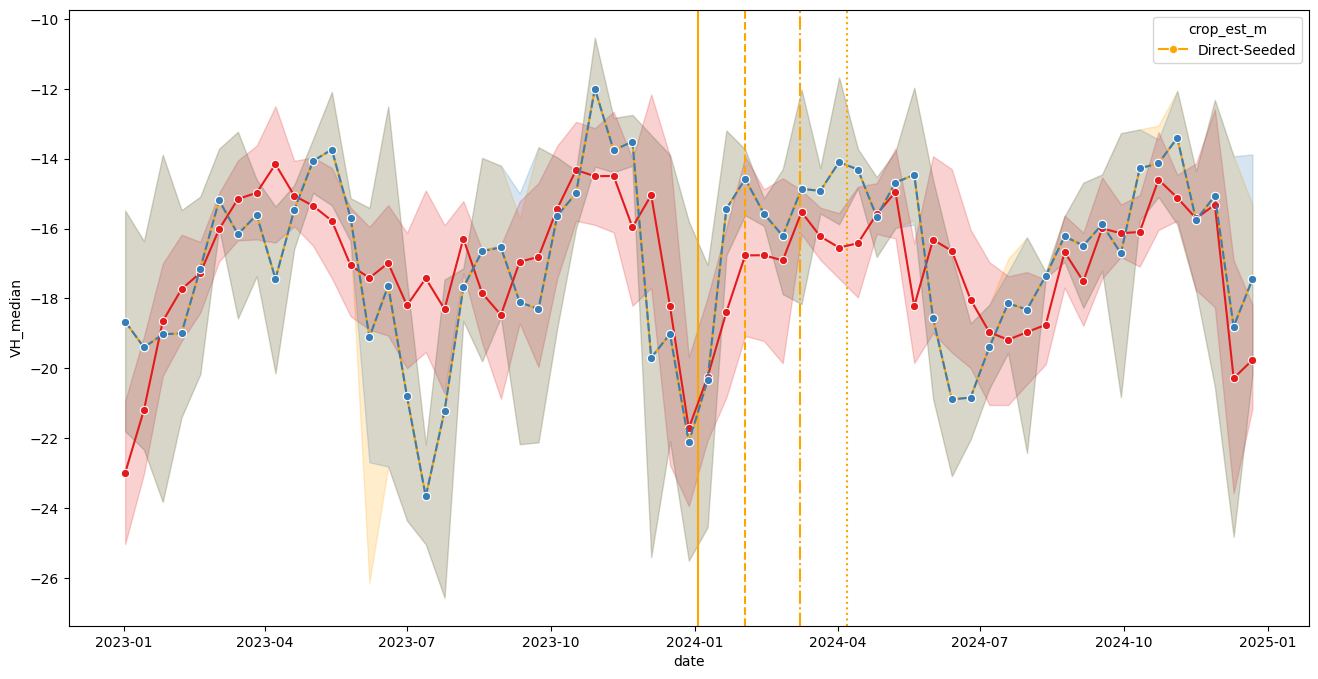

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

# Assuming your DataFrame is named 'df' and the column to smooth is 'VH_median'

# Convert 'date' column to datetime objects if it's not already
df['date'] = pd.to_datetime(df['date'])

# Sort the DataFrame by date (essential for time series smoothing)
df = df.sort_values('date')

# Function to evaluate smoothing performance (you can customize this)

def evaluate_smoothing(y_original, y_smoothed):
    """Evaluates the smoothing performance using Mean Squared Error (MSE)."""
    mse = np.mean((y_original - y_smoothed)**2)
    return mse

# Find the best 'frac' parameter using a simple search (you can refine this)

best_frac = None
best_mse = float('inf')  # Initialize with infinity

frac_values = np.arange(0.1, 1.0, 0.1)  # Test frac values from 0.1 to 0.9

for frac in frac_values:
    smoothed_data = lowess(df['VH_median'], df.index, frac=frac, return_sorted=False)
    mse = evaluate_smoothing(df['VH_median'], smoothed_data)
    print(f"frac: {frac:.1f}, MSE: {mse:.4f}") # Print MSE for each frac

    if mse < best_mse:
        best_mse = mse
        best_frac = frac

print(f"Best frac: {best_frac:.1f}, Best MSE: {best_mse:.4f}")

# Apply LOWESS smoothing with the best fraction
df['VH_median_smoothed'] = lowess(df['VH_median'], df.index, frac=best_frac, return_sorted=False)


# Define phase durations
VEGETATIVE_DAYS = 30
REPRODUCTIVE_DAYS = 35
RIPENING_DAYS = 30

# Set the color for Direct-Seeded crops to orange
colors = {'Direct-Seeded': 'orange'}

# Filter the dataframe for Direct-Seeded only
df_direct_seeded = df[df['crop_est_m'] == 'Direct-Seeded']

# Plot setup
plt.figure(figsize=(16, 8))  # Increased figure size for a larger plot

# Add the line plot for Direct-Seeded VH backscatter
sns.lineplot(
    data=df_direct_seeded,
    x='date',
    y=med,
    hue='crop_est_m',
    marker='o',
    style='crop_est_m',
    palette=colors
)

# Add vertical lines for crop establishment and phases for Direct-Seeded
for crop_type, group in df_direct_seeded.groupby('crop_est_m'):
    est_date = group['crop_est_d'].iloc[0]  # Use the first occurrence for the crop type

    # Calculate phase dates
    vegetative_date = est_date + pd.Timedelta(days=VEGETATIVE_DAYS)
    reproductive_date = vegetative_date + pd.Timedelta(days=REPRODUCTIVE_DAYS)
    ripening_date = reproductive_date + pd.Timedelta(days=RIPENING_DAYS)

    # Plot vertical lines for each phase
    plt.axvline(est_date, color=colors[crop_type], linestyle='-', label=f'{crop_type} Establishment Date')
    plt.axvline(vegetative_date, color=colors[crop_type], linestyle='--', label=f'{crop_type} Vegetative Phase')
    plt.axvline(reproductive_date, color=colors[crop_type], linestyle='-.', label=f'{crop_type} Reproductive Phase')
    plt.axvline(ripening_date, color=colors[crop_type], linestyle=':', label=f'{crop_type} Ripening Phase')

# Plot setup
#plt.figure(figsize=(16, 8))

# Add the line plot for original data
sns.lineplot(
    data=df,  # Use the entire DataFrame 'df' here
    x='date',
    y=med,  # Original 'med' data
    hue='crop_est_m',  # If you want to keep the hue
    marker='o',
    style='crop_est_m',
    palette='Set1',  # Use your color palette
    label='Original Data'
)

# Add the line plot for the smoothed data
sns.lineplot(
    data=df,  # Use the entire DataFrame 'df' here
    x='date',
    y='VH_median_smoothed',  # Smoothed data
    hue='crop_est_m',  # If you want to keep the hue
    marker='',
    style='crop_est_m',
    palette='Set2',  # Use your color palette
    linewidth=2,
    label='Smoothed Data'
)

# Add vertical lines for crop establishment and phases for Direct-Seeded
for crop_type, group in df_direct_seeded.groupby('crop_est_m'):
    est_date = group['crop_est_d'].iloc[0]  # Use the first occurrence for the crop type

    # Calculate phase dates
    vegetative_date = est_date + pd.Timedelta(days=VEGETATIVE_DAYS)
    reproductive_date = vegetative_date + pd.Timedelta(days=REPRODUCTIVE_DAYS)
    ripening_date = reproductive_date + pd.Timedelta(days=RIPENING_DAYS)

    # Plot vertical lines for each phase
    plt.axvline(est_date, color=colors[crop_type], linestyle='-', label=f'{crop_type} Establishment Date')
    plt.axvline(vegetative_date, color=colors[crop_type], linestyle='--', label=f'{crop_type} Vegetative Phase')
    plt.axvline(reproductive_date, color=colors[crop_type], linestyle='-.', label=f'{crop_type} Reproductive Phase')
    plt.axvline(ripening_date, color=colors[crop_type], linestyle=':', label=f'{crop_type} Ripening Phase')

# Customize the plot
plt.title('VV Backscatter and Crop Phases for Direct-Seeded Crops', fontsize=18)
plt.xlabel('Date', fontsize=16)
plt.ylabel('VV Median', fontsize=16)
plt.legend(title='Legend', fontsize=14, loc='upper right')

# Remove axis spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

# Remove grid lines and ticks extending from axis
plt.grid(False)  # Removes grid lines
plt.tick_params(axis='both', which='both', length=0)  # Removes tick marks

# Show the plot
plt.tight_layout()
plt.show()

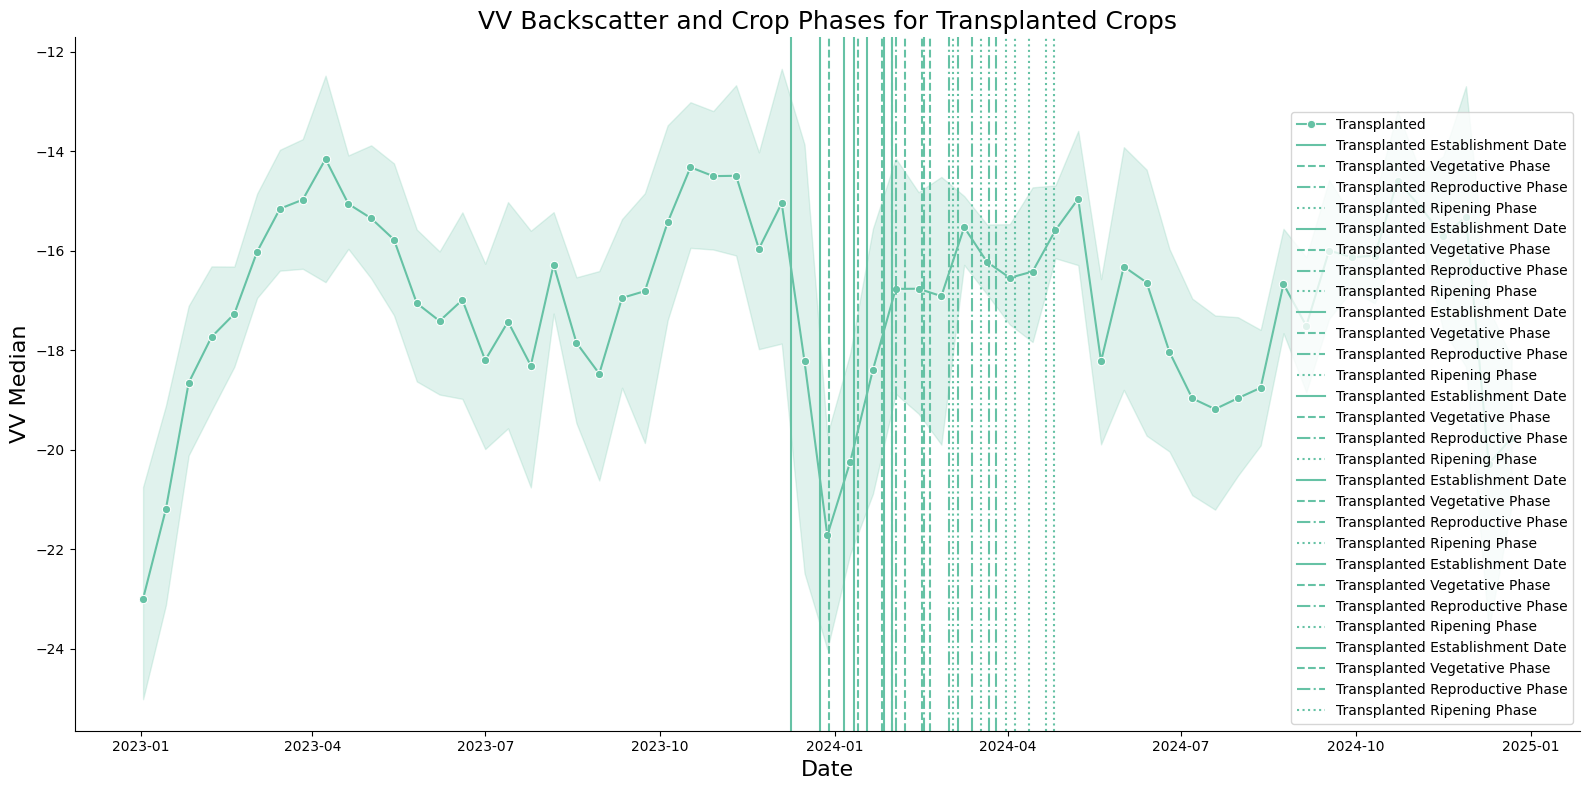

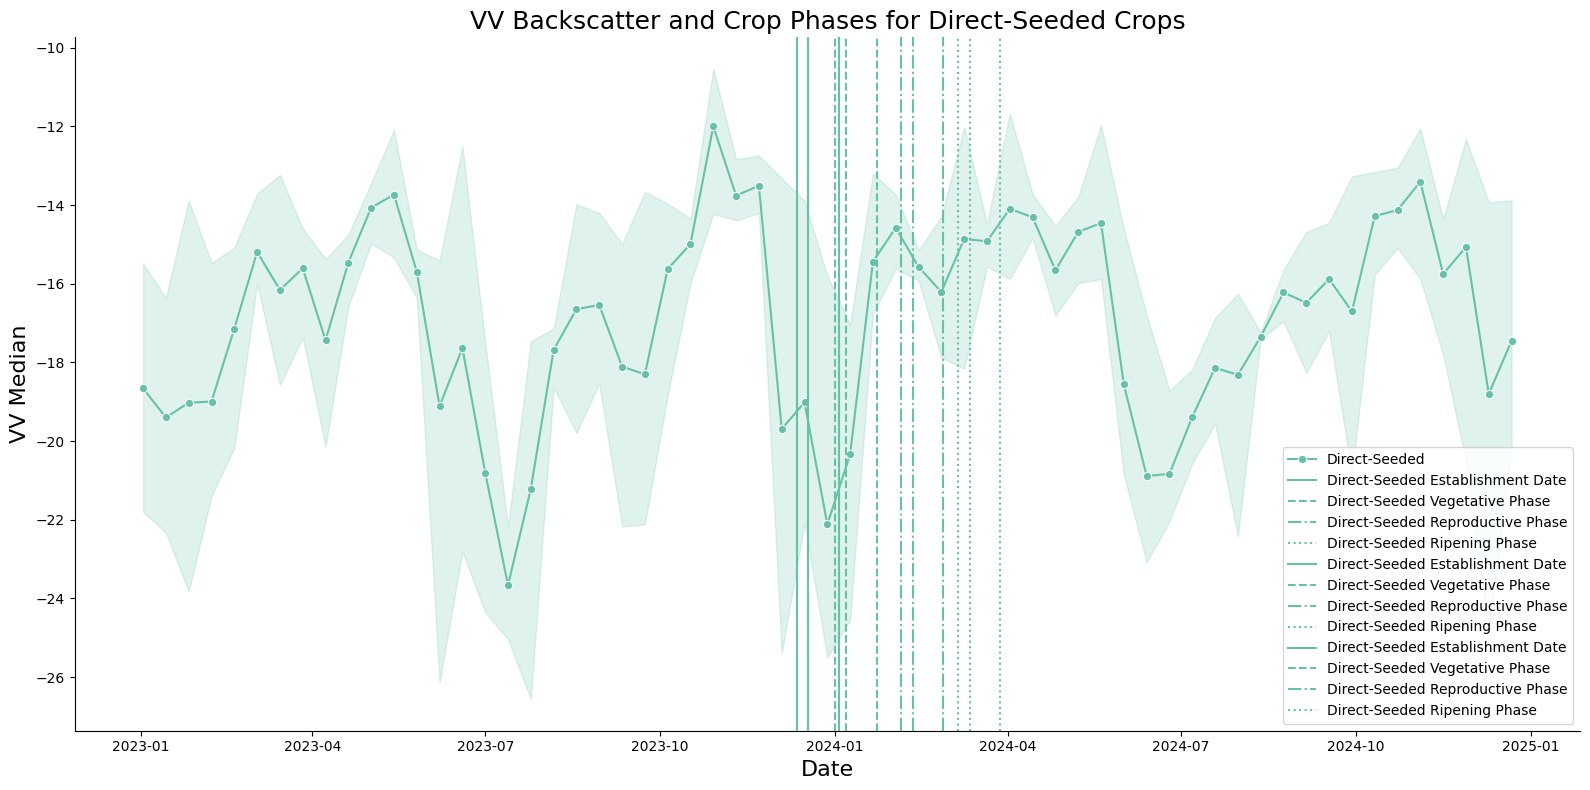

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ... (your code to read and preprocess the data) ...

VEGETATIVE_DAYS = 20
REPRODUCTIVE_DAYS = 35
RIPENING_DAYS = 30

palette = sns.color_palette('Set2') # Use the whole palette

for crop_type in df['crop_est_m'].unique():
    df_subset = df[df['crop_est_m'] == crop_type]
    plt.figure(figsize=(16, 8))
    sns.lineplot(data=df_subset, x='date', y='VH_median', hue='crop_est_m', marker='o', palette=palette)

    for est_date in df_subset['crop_est_d'].unique(): # Handle multiple establishment dates if present
        vegetative_date = est_date + pd.Timedelta(days=VEGETATIVE_DAYS)
        reproductive_date = vegetative_date + pd.Timedelta(days=REPRODUCTIVE_DAYS)
        ripening_date = reproductive_date + pd.Timedelta(days=RIPENING_DAYS)

        plt.axvline(est_date, color=palette[0], linestyle='-', label=f'{crop_type} Establishment Date')
        plt.axvline(vegetative_date, color=palette[0], linestyle='--', label=f'{crop_type} Vegetative Phase')
        plt.axvline(reproductive_date, color=palette[0], linestyle='-.', label=f'{crop_type} Reproductive Phase')
        plt.axvline(ripening_date, color=palette[0], linestyle=':', label=f'{crop_type} Ripening Phase')

    plt.title(f'VV Backscatter and Crop Phases for {crop_type} Crops', fontsize=18)
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('VV Median', fontsize=16)
    plt.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()